In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

In [28]:
df = pd.read_csv('Dataset/archive(2)/train.csv')

df.shape

(54808, 13)

In [29]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [30]:
df['previous_year_rating'].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
54803    False
54804    False
54805    False
54806    False
54807    False
Name: previous_year_rating, Length: 54808, dtype: bool

In [31]:
check_los_unqiue=df[df['previous_year_rating'].isnull()]

In [32]:
check_los_unqiue['length_of_service'].nunique()

1

In [33]:
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
education,2409,4.40
previous_year_rating,4124,7.52


## 1. Missing value treatment


In [34]:
df['previous_year_rating'].fillna(df['previous_year_rating'].median(), inplace=True)
df['education'] = df['education'].fillna('missing')

df[['education', 'previous_year_rating']].head()

/tmp/ipykernel_134531/1183856151.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['previous_year_rating'].fillna(df['previous_year_rating'].median(), inplace=True)


,education,previous_year_rating
0,Master's & above,5.0
1,Bachelor's,5.0
2,Bachelor's,3.0
3,Bachelor's,1.0
4,Bachelor's,3.0


## 2. Feature engineering

In [35]:
df['experience_ratio'] = (df['length_of_service'] / df['age']).round(3)
df['joining_age'] = df['age'] - df['length_of_service']
df['training_efficiency'] = (df['avg_training_score'] / df['no_of_trainings'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0).round(3)
df['training_frequency'] = (df['no_of_trainings'] / (df['length_of_service'] + 1)).round(3)
df['performance_score'] = df['previous_year_rating'] * df['avg_training_score']
df['award_score'] = df['awards_won?'] * df['avg_training_score']
df['score_per_age'] = (df['avg_training_score'] / df['age']).round(3)

df[['experience_ratio', 'joining_age', 'training_efficiency', 'training_frequency', 'performance_score']].head()

,experience_ratio,joining_age,training_efficiency,training_frequency,performance_score
0,0.229,27,49.0,0.111,245.0
1,0.133,26,60.0,0.200,300.0
2,0.206,27,50.0,0.125,150.0
3,0.256,29,25.0,0.182,50.0
4,0.044,43,73.0,0.333,219.0


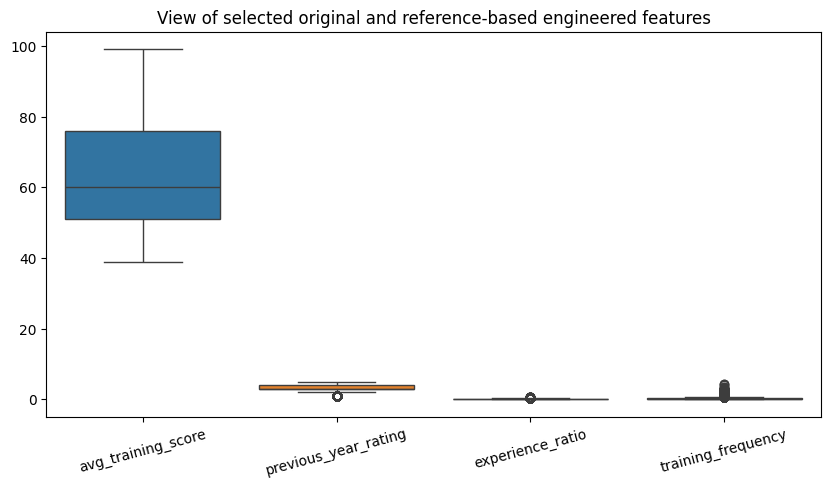

In [36]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['avg_training_score', 'previous_year_rating', 'experience_ratio', 'training_frequency']])
plt.title('View of selected original and reference-based engineered features')
plt.xticks(rotation=15)
plt.show()

## 3. Encoding

After the reference-style cleaning and numeric feature creation, categorical columns are one-hot encoded for selection.

In [37]:
target = df['is_promoted'].copy()

X = df.drop(columns=['employee_id', 'is_promoted'])

categorical_columns = ['department', 'region', 'education', 'gender', 'recruitment_channel']

X = pd.get_dummies(X, columns=categorical_columns, drop_first=True, dtype=int)
X.shape

(54808, 60)

## check drop first

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted,experience_ratio,joining_age,training_efficiency,training_frequency,performance_score,award_score,score_per_age
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0,0.229,27,49.0,0.111,245.0,0,1.400
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0,0.133,26,60.0,0.200,300.0,0,2.000
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0,0.206,27,50.0,0.125,150.0,0,1.471
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0,0.256,29,25.0,0.182,50.0,0,1.282
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0,0.044,43,73.0,0.333,219.0,0,1.622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0,0.354,31,78.0,0.056,234.0,0,1.625
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0,0.162,31,56.0,0.143,112.0,0,1.514
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0,0.111,24,79.0,0.250,395.0,0,2.926
54806,13614,Sales & Marketing,region_9,missing,m,sourcing,1,29,1.0,2,0,45,0,0.069,27,45.0,0.333,45.0,0,1.552


## 4. Feature review


In [38]:
y = target.copy()

mi_scores = pd.Series(mutual_info_classif(X, y, random_state=42), index=X.columns).sort_values(ascending=False)
mi_scores.head(15)

performance_score               0.039701
avg_training_score              0.030264
training_efficiency             0.028323
score_per_age                   0.021660
previous_year_rating            0.017843
award_score                     0.014468
awards_won?                     0.010369
gender_m                        0.010086
recruitment_channel_sourcing    0.006782
no_of_trainings                 0.004747
region_region_2                 0.003255
education_Master's & above      0.003204
department_Sales & Marketing    0.003089
region_region_17                0.002820
length_of_service               0.002781
dtype: float64

In [39]:
rf = RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced_subsample')
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_importance.head(15)

performance_score               0.112993
avg_training_score              0.099401
score_per_age                   0.091868
training_efficiency             0.085654
experience_ratio                0.071046
age                             0.057180
joining_age                     0.056569
previous_year_rating            0.049760
training_frequency              0.044640
length_of_service               0.039430
department_Sales & Marketing    0.021801
recruitment_channel_sourcing    0.019848
gender_m                        0.017773
award_score                     0.016938
awards_won?                     0.015686
dtype: float64

In [40]:
top_features = pd.DataFrame({
    'mutual_info': mi_scores,
    'rf_importance': rf_importance
}).fillna(0)

top_features['combined_rank'] = top_features['mutual_info'].rank(ascending=False) + top_features['rf_importance'].rank(ascending=False)
top_features = top_features.sort_values('combined_rank')
top_features.head(20)

,mutual_info,rf_importance,combined_rank
performance_score,0.039701,0.112993,2.0
avg_training_score,0.030264,0.099401,4.0
training_efficiency,0.028323,0.085654,7.0
score_per_age,0.021660,0.091868,7.0
previous_year_rating,0.017843,0.049760,13.0
award_score,0.014468,0.016938,20.0
recruitment_channel_sourcing,0.006782,0.019848,21.0
gender_m,0.010086,0.017773,21.0
awards_won?,0.010369,0.015686,22.0
department_Sales & Marketing,0.003089,0.021801,24.0


In [41]:
selected_columns = top_features.head(20).index.tolist()

train_selected = pd.concat([X[selected_columns], y], axis=1)

train_selected.to_csv('Dataset/archive(2)/train_fe_alternative.csv', index=False)

train_selected.head()

,performance_score,avg_training_score,training_efficiency,score_per_age,previous_year_rating,award_score,recruitment_channel_sourcing,gender_m,awards_won?,department_Sales & Marketing,...,length_of_service,training_frequency,region_region_2,education_Master's & above,no_of_trainings,department_Operations,age,experience_ratio,department_Procurement,is_promoted
0,245.0,49,49.0,1.400,5.0,0,1,0,0,1,...,8,0.111,0,1,1,0,35,0.229,0,0
1,300.0,60,60.0,2.000,5.0,0,0,1,0,0,...,4,0.200,0,0,1,1,30,0.133,0,0
2,150.0,50,50.0,1.471,3.0,0,1,1,0,1,...,7,0.125,0,0,1,0,34,0.206,0,0
3,50.0,50,25.0,1.282,1.0,0,0,1,0,1,...,10,0.182,0,0,2,0,39,0.256,0,0
4,219.0,73,73.0,1.622,3.0,0,0,1,0,0,...,2,0.333,0,0,1,0,45,0.044,0,0
